# Retrieving data from OpenStreetMap

## What is OpenStreetMap?

![The logo of OpenStreetMap (OSM)](images/osm-logo_256x256px.svg)

OpenStreetMap is a free and open map service, but - first and foremost - it is a collaborative global effort to collect free and open geodata. *Source: [wiki.openstreetmap.org](https://wiki.openstreetmap.org/wiki/Logos)*


OpenStreetMap (OSM) is a global collaborative (crowd-sourced) database and
project that aims at creating a free editable map of the world containing of
information about our environment. It contains data about streets, buildings,
different services, and landuse, to mention but a few.
The collected data is also basis for the map at [openstreetmap.org](https://openstreetmap.org/). 


> **Note: Contribute!**  
> You can also sign up as a contributor if you want to add to the database and map or correct and improve existing data. Read more in the [OpenStreetMap Wiki](https://wiki.openstreetmap.org/wiki/Main_Page).



OSM has more than 8 million registered users who contribute around 4 million
changes daily.  Its database contains data that is described by [more than 7
billion nodes](http://wiki.openstreetmap.org/wiki/Stats) (that make up lines,
polygons and other objects).

While the most well-known side of OpenStreetMap is the map itself, that [we
have used as a background map](../lesson-5/static-maps), the project is much
more than that. OSM’s data can be used for many other purposes such as
**routing**, **geocoding**, **education**, and **research**. OSM is also widely
used for humanitarian response, e.g., in crisis areas (e.g. after natural
disasters) and for fostering economic development. Read more about humanitarian
projects that use OSM data from the [Humanitarian OpenStreetMap Team (HOTOSM)
website](https://www.hotosm.org).



## Main tools in this lesson

### OSMnx

This week we will explore a Python package called
[OSMnx](https://github.com/gboeing/osmnx) that can be used to retrieve street
networks from OpenStreetMap, and construct, analyse, and visualise them. OSMnx
can also fetch data about Points of Interest, such as restaurants, schools, and
different kinds of services.  The package also includes tools to find routes on
a network downloaded from OpenStreetMap, and implements algorithms for finding
shortest connections for walking, cycling, or driving.


To get an overview of the capabilities of the package, watch the introductory
video given by the lead developer of the package, Prof. Geoff Boeing: ["Meet
the developer: Introduction to OSMnx package by Geoff
Boeing"](https://www.youtube.com/watch?v=Q0uxu25ddc4&list=PLs9D4XVqc6dCAhhvhZB7aHGD8fCeCC_6N).

There is also a scientific article available describing the package:

> Boeing, G. 2017. ["OSMnx: New Methods for Acquiring, Constructing, Analyzing,
> and Visualizing Complex Street
> Networks."](https://www.researchgate.net/publication/309738462_OSMnx_New_Methods_for_Acquiring_Constructing_Analyzing_and_Visualizing_Complex_Street_Networks)
> Computers, Environment and Urban Systems 65, 126-139.
> doi:10.1016/j.compenvurbsys.2017.05.004

[This
tutorial](https://github.com/gboeing/osmnx-examples/blob/master/notebooks/01-overview-osmnx.ipynb)
provides a practical overview of OSMnx functionalities, and has also inspired
this AutoGIS lesson.


### NetworkX

We will also use [NetworkX](https://networkx.github.io/documentation//)
to manipulate and analyse the street network data retrieved from
OpenStreetMap. NetworkX is a Python package that can be used to create,
manipulate, and study the structure, dynamics, and functions of complex
networks. 


---


## Download and visualise OpenStreetMap data with OSMnx

A useful feature of OSMnx is its easy-to-use tools to download
[OpenStreetMap](http://www.openstreetmap.org) data via the project’s [OverPass
API](http://wiki.openstreetmap.org/wiki/Overpass_API).
In this section, we will learn how to download and visualise the street network
and additional data from OpenStreetMap covering an area of interest.


### Street network

The [`osmnx.graph`
module](https://osmnx.readthedocs.io/en/stable/osmnx.html#module-osmnx.graph)
downloads data to construct a routable road network graph, based on an
user-defined area of interest. This area of interest can be specified, for
instance, using a place name, a bounding box, or a polygon.  Here, we will use
a placename for fetching data covering the Kamppi area in Helsinki, Finland. 

In the place name query, OSMnx uses the Nominatim Geocoding API. This means
that place names should exist in the OpenStreetMap database (run a test search
at [openstreetmap.org](https://www.openstreetmap.org/) or
[nominatim.openstreetmap.org](https://nomination.openstreetmap.org/)).

We will read an OSM street network using OSMnx’s
[graph_from_place()](https://osmnx.readthedocs.io/en/stable/osmnx.html#osmnx.graph.graph_from_place) function:

In [1]:
import osmnx

PLACE_NAME = "Kamppi, Helsinki, Finland"
graph = osmnx.graph_from_place(PLACE_NAME)

Check the data type of the graph:

In [2]:
type(graph)


networkx.classes.multidigraph.MultiDiGraph

What we have here is a
[`networkx.MultiDiGraph`](https://networkx.org/documentation/stable/reference/classes/multidigraph.html) object.


OSMnx’s graphs do not have a built-in method to plot them, but the package
comes with a function to do so:

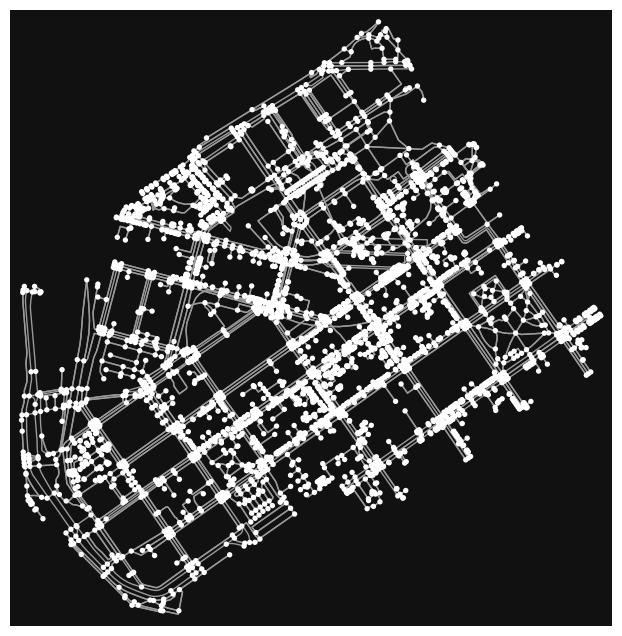

In [3]:
figure, ax = osmnx.plot_graph(graph)


Just as its GeoPandas and Pandas equivalents, `osmnx.plot_graph()` uses
matplotlib. The function returns a `(figure, axes)` tuple, that can be used to
modify the figure using all matplotlib functions we already got to know.

We can see that our graph contains nodes (the points) and edges (the
lines) that connects those nodes to each other.



### Convert a graph to `GeoDataFrame`s

The street network we just downloaded is a *graph*, more specifically a
`networkx.MultiDiGraph`. Its main purpose is to represent the topological
relationships between nodes and the links (edges) between them. Sometimes, it
is more convenient to have the underlying geodata in `geopandas.GeoDataFrame`s.
OSMnx comes with a convenient function that converts a graph into two geo-data
frames, one for nodes, and one for edges:
[`osmnx.graph_to_gdfs()`](https://osmnx.readthedocs.io/en/stable/osmnx.html#osmnx.utils_graph.graph_to_gdfs).

In [4]:
nodes, edges = osmnx.graph_to_gdfs(graph)


In [5]:
nodes.head()

,y,x,street_count,railway,highway,ref,geometry
osmid,,,,,,,
25216594,60.164794,24.921057,5,NaN,NaN,NaN,POINT (24.92106 60.16479)
25238874,60.163663,24.921029,4,tram_level_crossing,NaN,NaN,POINT (24.92103 60.16366)
25238883,60.163452,24.921441,4,NaN,crossing,NaN,POINT (24.92144 60.16345)
25238933,60.161114,24.924529,3,NaN,NaN,NaN,POINT (24.92453 60.16111)
25238937,60.160860,24.925861,3,NaN,NaN,NaN,POINT (24.92586 60.16086)


In [6]:
edges.head()

osmid   highway lanes maxspeed            name  \
u        v          key                                                       
25216594 1372425721 0     23717777   primary     2       40   Porkkalankatu   
         1372425714 0     23856784   primary     2       40  Mechelininkatu   
25238874 336192701  0     29977177   primary     3       40  Mechelininkatu   
         1519889266 0    930820886  tertiary     1       30    Itämerenkatu   
25238883 568147264  0     58077048   primary     4       40  Mechelininkatu   

                         oneway reversed     length  \
u        v          key                               
25216594 1372425721 0      True    False  10.403735   
         1372425714 0      True    False  40.885163   
25238874 336192701  0      True    False   6.100724   
         1519889266 0      True    False  10.885283   
25238883 568147264  0      True    False  15.388095   

                                                                  geometry  \
u        v          key                                                      
25216594 1372425721 0    LINESTRING (24.92106 60.16479, 24.92087 60.16479)   
         1372425714 0    LINESTRING (24.92106 60.16479, 24.92095 60.164...   
25238874 336192701  0    LINESTRING (24.92103 60.16366, 24.92104 60.16361)   
         1519889266 0    LINESTRING (24.92103 60.16366, 24.92083 60.16366)   
25238883 568147264  0     LINESTRING (24.92144 60.16345, 24.9214 60.16359)   

                        junction width tunnel access service bridge  
u        v          key                                              
25216594 1372425721 0        NaN   NaN    NaN    NaN     NaN    NaN  
         1372425714 0        NaN   NaN    NaN    NaN     NaN    NaN  
25238874 336192701  0        NaN   NaN    NaN    NaN     NaN    NaN  
         1519889266 0        NaN   NaN    NaN    NaN     NaN    NaN  
25238883 568147264  0        NaN   NaN    NaN    NaN     NaN    NaN

Nice! Now, as we can see, we have our graph as GeoDataFrames and we can plot
them using the same functions and tools as we have used before.



### Place polygon

Let’s also plot the polygon that represents our area of interest (Kamppi,
Helsinki). We can retrieve the polygon geometry using the
[osmnx.geocode_to_gdf()](https://osmnx.readthedocs.io/en/stable/osmnx.html?highlight=geocode_to_gdf(#osmnx.geocoder.geocode_to_gdf)
function.

In [7]:
# Get place boundary related to the place name as a geodataframe
area = osmnx.geocode_to_gdf(PLACE_NAME)

As the name of the function already tells us, it returns a GeoDataFrame object
based on the specified place name query.  Let’s still verify the data type:

In [8]:
type(area)

geopandas.geodataframe.GeoDataFrame

Let’s also have a look at the data:

In [9]:
area.head()

,geometry,bbox_west,bbox_south,bbox_east,bbox_north,place_id,osm_type,osm_id,lat,lon,class,type,place_rank,importance,addresstype,name,display_name
0,"POLYGON ((24.92064 60.16483, 24.92069 60.16447...",24.920643,60.160469,24.943464,60.172075,154404240,relation,184714,60.167626,24.931709,boundary,administrative,20,0.466964,suburb,Kamppi,"Kamppi, Southern major district, Helsinki, Hel..."


<Axes: >

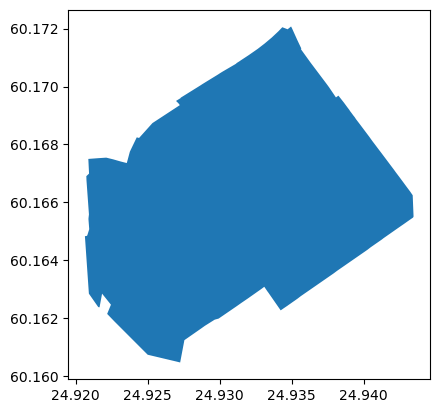

In [10]:
area.plot()

### Building footprints

Besides network data, OSMnx can also download any other data contained in the OpenStreetMap database. This includes, for instance, building footprints, and different points-of-interests (POIs). To download arbitrary geometries, filtered by [OSM tags](https://wiki.openstreetmap.org/wiki/Map_features) and a place name, use [`osmnx.features_from_place()`](https://osmnx.readthedocs.io/en/stable/osmnx.html#osmnx.features_from_place) [geometries is now deprecated]. The tag to retrieve all [buildings](https://wiki.openstreetmap.org/wiki/Buildings) is `building = True`.

In [12]:
buildings = osmnx.features_from_place(
    PLACE_NAME,
    {"building": True},
)

In [13]:
len(buildings)

453

In [14]:
buildings.head()

geometry  \
element  id                                                               
node     11711721042                           POINT (24.92714 60.1642)   
relation 4701         POLYGON ((24.93219 60.16342, 24.93209 60.16349...   
         5603         POLYGON ((24.93696 60.16574, 24.93791 60.16607...   
         5605         POLYGON ((24.93758 60.16662, 24.93788 60.16672...   
         5606         POLYGON ((24.9396 60.16731, 24.93964 60.16729,...   

                     addr:city addr:housenumber addr:postcode  addr:street  \
element  id                                                                  
node     11711721042  Helsinki               46         00180  Eerikinkatu   
relation 4701              NaN              NaN           NaN          NaN   
         5603              NaN              NaN           NaN          NaN   
         5605              NaN              NaN           NaN          NaN   
         5606              NaN              NaN           NaN          NaN   

                        building                   name      opening_hours  \
element  id                                                                  
node     11711721042         yes  Nice Bike Pyörähuolto  Mo-Fr 11:00-18:00   
relation 4701                yes                    NaN                NaN   
         5603                yes                    NaN                NaN   
         5605         apartments                    NaN                NaN   
         5606              hotel              Suomitalo                NaN   

                          operator           phone  ... unisex covered area  \
element  id                                         ...                       
node     11711721042  Nice Bike Oy  +358 452250669  ...    NaN     NaN  NaN   
relation 4701                  NaN             NaN  ...    NaN     NaN  NaN   
         5603                  NaN             NaN  ...    NaN     NaN  NaN   
         5605                  NaN             NaN  ...    NaN     NaN  NaN   
         5606                  NaN             NaN  ...    NaN     NaN  NaN   

                     leisure construction          type  ele electrified  \
element  id                                                                
node     11711721042     NaN          NaN           NaN  NaN         NaN   
relation 4701            NaN          NaN  multipolygon  NaN         NaN   
         5603            NaN          NaN  multipolygon  NaN         NaN   
         5605            NaN          NaN  multipolygon  NaN         NaN   
         5606            NaN          NaN  multipolygon  NaN         NaN   

                     nohousenumber note  
element  id                              
node     11711721042           NaN  NaN  
relation 4701                  NaN  NaN  
         5603                  NaN  NaN  
         5605                  NaN  NaN  
         5606                  NaN  NaN  

[5 rows x 122 columns]

As you can see, there are several columns in `buildings`. Each column contains
information about a specific tag that OpenStreetMap contributors have added.
Each tag consists of a key (the column name), and a values (for example
`building=yes` or `building=school`). Read more about tags and tagging
practices in the [OpenStreetMap
wiki](https://wiki.openstreetmap.org/wiki/Tags).

In [15]:
buildings.columns

Index(['geometry', 'addr:city', 'addr:housenumber', 'addr:postcode',
       'addr:street', 'building', 'name', 'opening_hours', 'operator', 'phone',
       ...
       'unisex', 'covered', 'area', 'leisure', 'construction', 'type', 'ele',
       'electrified', 'nohousenumber', 'note'],
      dtype='object', length=122)

### Points-of-interest

Point-of-interest (POI) is a generic concept that describes point locations
that represent places of interest. As `osmnx.features_from_place()` can download any geometry data contained in the OpenStreetMap database, it can also be used to download any kind of POI data. 


In OpenStreetMap, many POIs are described using the [`amenity`
tag](https://wiki.openstreetmap.org/wiki/Key:amenity).  We can, for example,
retrieve all restaurant locations by querying `amenity=restaurant`.

In [16]:
restaurants = osmnx.features_from_place(
    PLACE_NAME,
    {
        "amenity": "restaurant"
    }
)
len(restaurants)

165

As we can see, there are quite many restaurants in the area.

Let’s explore what kind of attributes we have in our restaurants GeoDataFrame:

In [17]:
restaurants.columns.values

array(['geometry', 'addr:city', 'addr:country', 'addr:housenumber',
       'addr:postcode', 'addr:street', 'amenity', 'cuisine', 'diet:halal',
       'diet:kosher', 'name', 'payment:credit_cards',
       'payment:debit_cards', 'phone', 'website', 'wheelchair', 'email',
       'facebook', 'indoor_seating', 'level', 'opening_hours',
       'outdoor_seating', 'short_name', 'start_date',
       'toilets:wheelchair', 'check_date', 'delivery:covid19',
       'opening_hours:covid19', 'takeaway:covid19', 'diet:vegetarian',
       'name:fi', 'name:zh', 'payment:cash', 'diet:vegan',
       'disused:amenity', 'addr:housename', 'access:covid19',
       'drive_through:covid19', 'takeaway', 'toilets',
       'check_date:diet:vegetarian', 'contact:phone', 'contact:website',
       'source', 'capacity', 'smoking', 'dog', 'operator', 'shop',
       'air_conditioning', 'alt_name', 'internet_access', 'contact:email',
       'contact:facebook', 'established', 'opening_hours:kitchen',
       'description',

As you can see, there is quite a lot of (potential) information related to the
amenities. Let’s subset the columns and inspect the data further. Can we
extract all restaurants’ names, address, and opening hours?

In [18]:
# Select some useful cols and print
interesting_columns = [
    "name",
    "opening_hours",
    "addr:city",
    "addr:country",
    "addr:housenumber",
    "addr:postcode",
    "addr:street"
]

# Print only selected cols
restaurants[interesting_columns].head(10)

name  \
element id                                   
node    60062502                    Kabuki   
        62965963   Restaurant & Bar Fusion   
        76617692              Johan Ludvig   
        76624339                   Shinobi   
        76624351                    Pueblo   
        151006260          Ravintola China   
        151006483                    Sekel   
        151006932               Haru Sushi   
        151007074                     Koto   
        248343226                  Mei Lin   

                                                       opening_hours  \
element id                                                             
node    60062502                                                 NaN   
        62965963                  Mo-Th 11-22; Fr-Sa 11-02; Su 12-20   
        76617692                                                 NaN   
        76624339                We-Th 17:00-23:00; Fr-Sa 16:00-24:00   
        76624351                                                 NaN   
        151006260       Mo-Fr 11:00-23:00; Sa-Su 12:00-23:00; PH off   
        151006483                                                NaN   
        151006932  Mo-Fr 11:00-21:00; Sa 12:00-21:00; Su 13:00-21:00   
        151007074                                                NaN   
        248343226               Tu-Fr 11:00-21:30; Sa,Su 12:00-21:30   

                  addr:city addr:country addr:housenumber addr:postcode  \
element id                                                                
node    60062502   Helsinki           FI               12         00180   
        62965963        NaN          NaN              NaN           NaN   
        76617692   Helsinki           FI              NaN           NaN   
        76624339   Helsinki           FI               38         00120   
        76624351   Helsinki           FI              NaN           NaN   
        151006260  Helsinki           FI               25         00100   
        151006483  Helsinki           FI                7         00120   
        151006932  Helsinki           FI               30         00120   
        151007074  Helsinki           FI               22         00120   
        248343226  Helsinki           FI               29         00100   

                       addr:street  
element id                          
node    60062502   Lapinlahdenkatu  
        62965963               NaN  
        76617692               NaN  
        76624339      Albertinkatu  
        76624351       Eerikinkatu  
        151006260        Annankatu  
        151006483        Bulevardi  
        151006932    Fredrikinkatu  
        151007074    Lönnrotinkatu  
        248343226        Annankatu

:::{tip}
if some of the information needs an update, head over to [openstreetmap.org](https://openstreetmap.org) and edit the source data!
:::



### Parks and green areas

Let’s try to fetch all public parks in the Kamppi area. In OpenStreetMap,
[parks hould be tagged](https://wiki.openstreetmap.org/wiki/Map_features) as
`leisure = park`.  Smaller green areas (*puistikot*) are sometimes also tagged
`landuse = grass`. We can combine multiple tags in one data query.

In [19]:
parks = osmnx.features_from_place(
    PLACE_NAME,
    {
        "leisure": "park",
        "landuse": "grass",
    },
)

<Axes: >

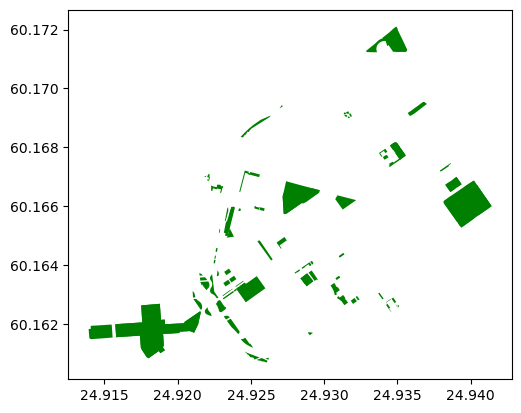

In [20]:
parks.plot(color="green")


### Plotting the data

Let’s create a map out of the streets, buildings, restaurants, and the area polygon.

<Axes: >

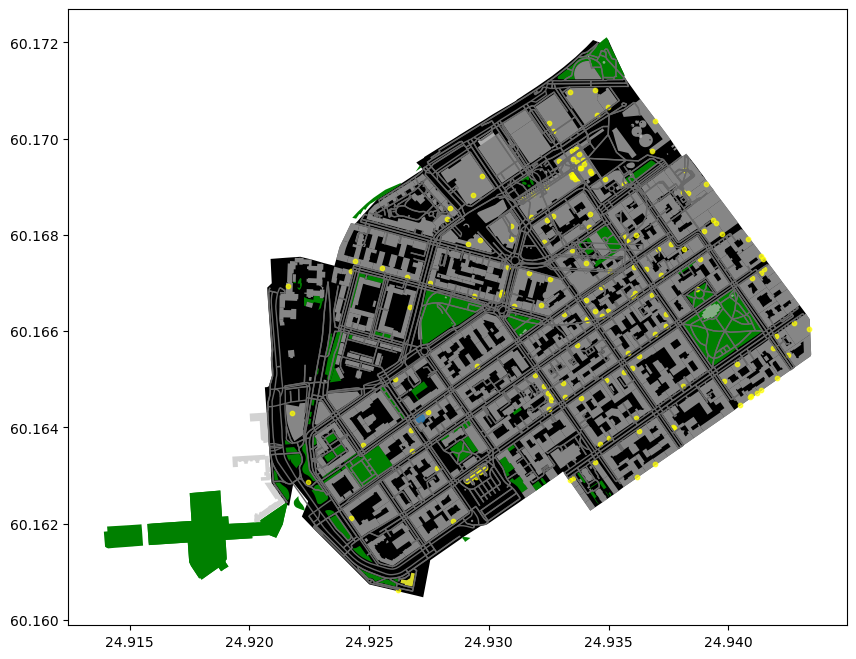

In [21]:
import matplotlib
figure, ax = matplotlib.pyplot.subplots(figsize=(12,8))

# Plot the footprint
area.plot(ax=ax, facecolor="black")

# Plot parks
parks.plot(ax=ax, facecolor="green")

# Plot street ‘edges’
edges.plot(ax=ax, linewidth=1, edgecolor="dimgray")

# Plot buildings
buildings.plot(ax=ax, facecolor="silver", alpha=0.7)

# Plot restaurants
restaurants.plot(ax=ax, color="yellow", alpha=0.7, markersize=10)

Cool! Now we have a map where we have plotted the restaurants, buildings,
streets and the boundaries of the selected region of ‘Kamppi’ in Helsinki. And
all of this required only a few lines of code. Pretty neat! 



> **Hint: Check your understanding**  
> Retrieve OpenStreetMap data from some other area! Download these elements using OSMnx functions from your area of interest:
> 
> - Extent of the area using `geocode_to_gdf()`
> - Street network using `graph_from_place()`, and convert to geo-data frame using `graph_to_gdfs()`
> - Building footprints (and other geometries) using `features_from_place()` and appropriate tags.
> 
> *Note: The larger the area you choose, the longer it takes to retrieve data from the API!*


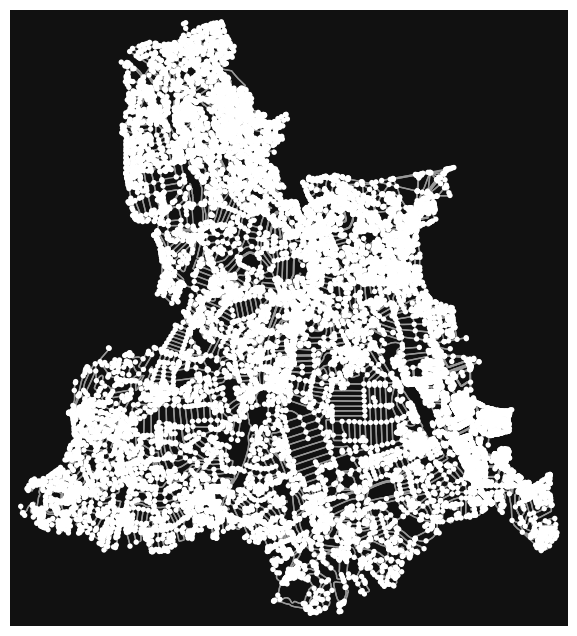

In [24]:
# Specify the name that is used to seach for the data. Check that the place
# name is valid from https://nominatim.openstreetmap.org/ui/search.html
MY_PLACE = "Lewisham, London, England"

# Get street network
graph = osmnx.graph_from_place(MY_PLACE)
figure, ax = osmnx.plot_graph(graph)

In [25]:
nodes, edges = osmnx.graph_to_gdfs(graph)

In [26]:
nodes.head()

,y,x,street_count,highway,railway,geometry
osmid,,,,,,
105122,51.469552,-0.028269,4,NaN,NaN,POINT (-0.02827 51.46955)
105123,51.460751,-0.034422,3,traffic_signals,NaN,POINT (-0.03442 51.46075)
105125,51.463035,-0.035792,3,NaN,NaN,POINT (-0.03579 51.46304)
105127,51.460470,-0.034167,3,NaN,NaN,POINT (-0.03417 51.46047)
105128,51.459278,-0.033897,3,NaN,NaN,POINT (-0.0339 51.45928)


In [27]:
edges.head()

osmid      highway maxspeed  \
u      v          key                                                  
105122 684418452  0                  651852806     tertiary   20 mph   
       280610835  0                   25732787  residential   20 mph   
       98208092   0    [338121120, 1069315449]     tertiary   20 mph   
105123 105127     0                    4411956    secondary   20 mph   
       2134751948 0                  584743994    secondary   20 mph   

                                name  oneway reversed      length  \
u      v          key                                               
105122 684418452  0     Wickham Road   False    False    4.638603   
       280610835  0     Lloyd Villas   False    False  108.598013   
       98208092   0     Wickham Road   False     True   73.668571   
105123 105127     0    Brockley Road   False     True   35.930235   
       2134751948 0    Brockley Road   False    False   29.394953   

                                                                geometry  \
u      v          key                                                      
105122 684418452  0    LINESTRING (-0.02827 51.46955, -0.02824 51.46959)   
       280610835  0    LINESTRING (-0.02827 51.46955, -0.02763 51.469...   
       98208092   0    LINESTRING (-0.02827 51.46955, -0.02841 51.469...   
105123 105127     0    LINESTRING (-0.03442 51.46075, -0.03417 51.46047)   
       2134751948 0    LINESTRING (-0.03442 51.46075, -0.03467 51.46097)   

                        ref access lanes service bridge tunnel width  \
u      v          key                                                  
105122 684418452  0     NaN    NaN   NaN     NaN    NaN    NaN   NaN   
       280610835  0     NaN    NaN   NaN     NaN    NaN    NaN   NaN   
       98208092   0     NaN    NaN   NaN     NaN    NaN    NaN   NaN   
105123 105127     0    B218    NaN   NaN     NaN    NaN    NaN   NaN   
       2134751948 0    B218    NaN   NaN     NaN    NaN    NaN   NaN   

                      est_width junction  
u      v          key                     
105122 684418452  0         NaN      NaN  
       280610835  0         NaN      NaN  
       98208092   0         NaN      NaN  
105123 105127     0         NaN      NaN  
       2134751948 0         NaN      NaN

<Axes: >

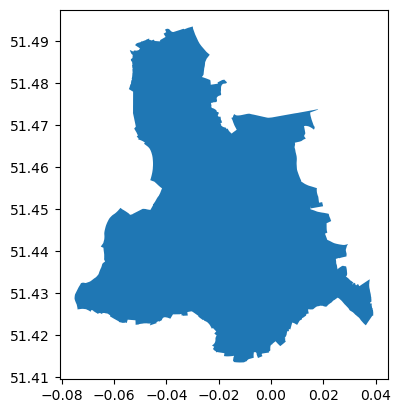

In [35]:
area = osmnx.geocode_to_gdf(MY_PLACE)
area.plot()

In [37]:
fast_food = osmnx.features_from_place(
    MY_PLACE,
    {
        "amenity": "fast_food"
    }
)
len(fast_food)

232

In [40]:
parks = osmnx.features_from_place(
    MY_PLACE,
    {
        "leisure": "park",
        "landuse": "grass",
    },
)

<Axes: >

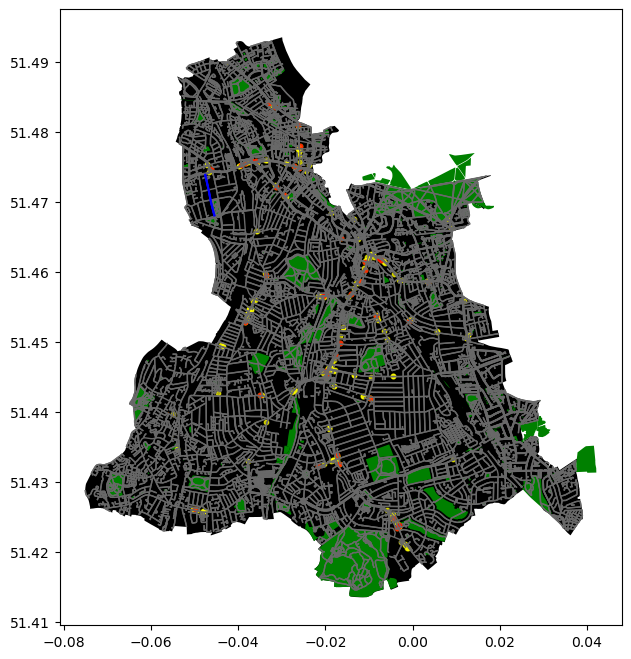

In [67]:
figure, ax = matplotlib.pyplot.subplots(figsize=(12,8))

# Plot the footprint
area.plot(ax=ax, facecolor="black")

# Plot parks
parks.plot(ax=ax, facecolor="green")

# Plot street ‘edges’
edges.plot(ax=ax, linewidth=1, edgecolor="dimgray")

# Plot restaurants
fast_food.plot(ax=ax, color="yellow", alpha=0.7, markersize=10)

#Plot Chicken Shops
fast_food[fast_food['cuisine'].str.contains('chicken')==True].plot(ax=ax, color="red", alpha=0.7, markersize=10)

#Plot Erlanger Shops
edges[edges['name'].str.contains('Erlanger')==True].plot(ax=ax, color="blue", alpha=1, markersize=10)



In [66]:
edges[edges['name'].str.contains('Erlanger')==True]

osmid      highway maxspeed           name  \
u           v           key                                                 
60677390    7113381481  0    8099003  residential   20 mph  Erlanger Road   
60677935    60677936    0    8099003  residential   20 mph  Erlanger Road   
            11501397720 0    8099003  residential   20 mph  Erlanger Road   
60677936    7276888002  0    8099003  residential   20 mph  Erlanger Road   
            60677935    0    8099003  residential   20 mph  Erlanger Road   
60677937    7276888002  0    8099003  residential   20 mph  Erlanger Road   
1017795942  11501397720 0    8099003  residential   20 mph  Erlanger Road   
            1017795952  0    8099003  residential   20 mph  Erlanger Road   
1017795952  1017795942  0    8099003  residential   20 mph  Erlanger Road   
            7113381481  0    8099003  residential   20 mph  Erlanger Road   
7113381481  60677390    0    8099003  residential   20 mph  Erlanger Road   
            1017795952  0    8099003  residential   20 mph  Erlanger Road   
7276888002  60677937    0    8099003  residential   20 mph  Erlanger Road   
            60677936    0    8099003  residential   20 mph  Erlanger Road   
11501397720 1017795942  0    8099003  residential   20 mph  Erlanger Road   
            60677935    0    8099003  residential   20 mph  Erlanger Road   

                             oneway reversed      length  \
u           v           key                                
60677390    7113381481  0     False    False    6.726200   
60677935    60677936    0     False    False  164.034344   
            11501397720 0     False     True  171.004373   
60677936    7276888002  0     False    False   96.573710   
            60677935    0     False     True  164.034344   
60677937    7276888002  0     False     True  170.328779   
1017795942  11501397720 0     False    False   33.161819   
            1017795952  0     False     True    2.765710   
1017795952  1017795942  0     False    False    2.765710   
            7113381481  0     False     True   47.437464   
7113381481  60677390    0     False     True    6.726200   
            1017795952  0     False    False   47.437464   
7276888002  60677937    0     False    False  170.328779   
            60677936    0     False     True   96.573710   
11501397720 1017795942  0     False     True   33.161819   
            60677935    0     False    False  171.004373   

                                                                      geometry  \
u           v           key                                                      
60677390    7113381481  0    LINESTRING (-0.04761 51.47402, -0.04759 51.47396)   
60677935    60677936    0    LINESTRING (-0.04678 51.47173, -0.04667 51.471...   
            11501397720 0    LINESTRING (-0.04678 51.47173, -0.04691 51.472...   
60677936    7276888002  0    LINESTRING (-0.04634 51.47028, -0.04623 51.469...   
            60677935    0    LINESTRING (-0.04634 51.47028, -0.04646 51.470...   
60677937    7276888002  0    LINESTRING (-0.04541 51.46795, -0.04544 51.468...   
1017795942  11501397720 0    LINESTRING (-0.04743 51.47352, -0.04732 51.47323)   
            1017795952  0    LINESTRING (-0.04743 51.47352, -0.04744 51.47355)   
1017795952  1017795942  0    LINESTRING (-0.04744 51.47355, -0.04743 51.47352)   
            7113381481  0    LINESTRING (-0.04744 51.47355, -0.04748 51.473...   
7113381481  60677390    0    LINESTRING (-0.04759 51.47396, -0.04761 51.47402)   
            1017795952  0    LINESTRING (-0.04759 51.47396, -0.04748 51.473...   
7276888002  60677937    0    LINESTRING (-0.04602 51.46944, -0.04588 51.469...   
            60677936    0    LINESTRING (-0.04602 51.46944, -0.04623 51.469...   
11501397720 1017795942  0    LINESTRING (-0.04732 51.47323, -0.04743 51.47352)   
            60677935    0    LINESTRING (-0.04732 51.47323, -0.04731 51.473...   

                             ref access lanes service bridge tunnel width  \
u        

## Advanced reading

To analyse OpenStreetMap data over large areas, it is often more efficient and
meaningful to download the data all at once, instead of separate queries to the
API. Such data dumps from OpenStreetMap are available in various file formats,
OSM [Protocolbuffer Binary
Format](https://wiki.openstreetmap.org/wiki/PBF_Format) (PBF) being one of
them. Data extracts covering whole countries and continents are available, for
instance, at [download.geofabrik.de](https://download.geofabrik.de/).

[Pyrosm](https://pyrosm.readthedocs.io/) is a Python package for reading
OpenStreetMap data from PBF files into `geopandas.GeoDataFrames`. Pyrosm makes
it easy to extract road networks, buildings, Points of Interest (POI), landuse,
natural elements, administrative boundaries and much more - similar to OSMnx,
but taylored to analyses of large areas.  While OSMnx reads the data from the
Overpass API, pyrosm reads the data from a local PBF file.

Read more about fetching and using pbf files as a source for analysing
OpenStreetMap data in Python from the [pyrosm
documentation](https://pyrosm.readthedocs.io/en/latest/basics.html#protobuf-file-what-is-it-and-how-to-get-one).